## 1) Objective

Professional data quality validation for Instacart raw data.

This notebook provides a repeatable quality workflow:
- standardized table profiling
- missing and duplicate diagnostics
- key integrity checks (PK/FK)
- domain/range rule validation
- issue register with severity and status
- exportable quality reports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Resolve raw-data directory from either project root or notebook directory
candidate_dirs = [Path('data/raw'), Path('../../data/raw')]
data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError('Cannot find data/raw directory from current working directory.')

orders = pd.read_csv(data_dir / 'orders.csv')
order_products_prior = pd.read_csv(data_dir / 'order_products__prior.csv')
order_products_train = pd.read_csv(data_dir / 'order_products__train.csv')
products = pd.read_csv(data_dir / 'products.csv')
aisles = pd.read_csv(data_dir / 'aisles.csv')
departments = pd.read_csv(data_dir / 'departments.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments,
}

print(f'Loaded {len(tables)} tables from: {data_dir.resolve()}')

Loaded 6 tables from: /home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/data/raw


## 2) Quality Check Framework

In [3]:
def profile_tables(table_dict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, df in table_dict.items():
        rows.append(
            {
                'table': name,
                'rows': df.shape[0],
                'cols': df.shape[1],
                'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
                'duplicate_rows': int(df.duplicated().sum()),
                'missing_cells': int(df.isna().sum().sum()),
                'missing_pct_cells': round((df.isna().sum().sum() / df.size) * 100, 4),
            }
        )
    return pd.DataFrame(rows).sort_values(['missing_cells', 'duplicate_rows'], ascending=False)


def column_missing(table_dict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    records = []
    for name, df in table_dict.items():
        for col in df.columns:
            miss_count = int(df[col].isna().sum())
            if miss_count > 0:
                records.append(
                    {
                        'table': name,
                        'column': col,
                        'missing_count': miss_count,
                        'missing_pct': round(df[col].isna().mean() * 100, 4),
                    }
                )
    if not records:
        return pd.DataFrame(columns=['table', 'column', 'missing_count', 'missing_pct'])
    return pd.DataFrame(records).sort_values(['missing_pct', 'missing_count'], ascending=False)


def check_pk_unique(df: pd.DataFrame, table_name: str, key_col: str) -> dict:
    non_null_count = int(df[key_col].notna().sum())
    unique_non_null = int(df[key_col].nunique(dropna=True))
    pass_flag = bool(df[key_col].is_unique and non_null_count == len(df))
    return {
        'check_type': 'PK_UNIQUENESS',
        'table': table_name,
        'column': key_col,
        'status': 'PASS' if pass_flag else 'FAIL',
        'invalid_count': int(len(df) - unique_non_null),
        'severity': 'critical',
        'detail': f'non_null={non_null_count}, unique_non_null={unique_non_null}, rows={len(df)}',
    }


def check_fk_coverage(child_df: pd.DataFrame, child_table: str, child_col: str, parent_df: pd.DataFrame, parent_table: str, parent_col: str, severity: str = 'critical') -> dict:
    coverage = float(child_df[child_col].isin(parent_df[parent_col]).mean() * 100)
    invalid_count = int((~child_df[child_col].isin(parent_df[parent_col])).sum())
    pass_flag = invalid_count == 0
    return {
        'check_type': 'FK_COVERAGE',
        'table': child_table,
        'column': child_col,
        'status': 'PASS' if pass_flag else 'FAIL',
        'invalid_count': invalid_count,
        'severity': severity,
        'detail': f'{child_table}.{child_col} in {parent_table}.{parent_col} = {coverage:.4f}%',
    }


def check_range(df: pd.DataFrame, table_name: str, col: str, min_val: float, max_val: float, severity: str = 'major') -> dict:
    invalid_mask = ~df[col].between(min_val, max_val)
    invalid_count = int(invalid_mask.sum())
    return {
        'check_type': 'RANGE',
        'table': table_name,
        'column': col,
        'status': 'PASS' if invalid_count == 0 else 'FAIL',
        'invalid_count': invalid_count,
        'severity': severity,
        'detail': f'expected between [{min_val}, {max_val}]',
    }


def check_allowed_set(df: pd.DataFrame, table_name: str, col: str, allowed_values: set, severity: str = 'major') -> dict:
    invalid_mask = ~df[col].isin(allowed_values)
    invalid_count = int(invalid_mask.sum())
    return {
        'check_type': 'ALLOWED_SET',
        'table': table_name,
        'column': col,
        'status': 'PASS' if invalid_count == 0 else 'FAIL',
        'invalid_count': invalid_count,
        'severity': severity,
        'detail': f'allowed={sorted(allowed_values)}',
    }

## 3) Profiling and Missing Diagnostics

In [4]:
missing_df = column_missing(tables)
missing_df.head(30)

,table,column,missing_count,missing_pct
0,orders,days_since_prior_order,206209,6.0276


In [5]:
profile_df = profile_tables(tables)
profile_df

,table,rows,cols,memory_mb,duplicate_rows,missing_cells,missing_pct_cells
0,orders,3421083,7,332.7100,0,206209,0.8611
1,order_products_prior,32434489,4,989.8200,0,0,0.0000
2,order_products_train,1384617,4,42.2600,0,0,0.0000
3,products,49688,4,4.9300,0,0,0.0000
4,aisles,134,2,0.0100,0,0,0.0000
5,departments,21,2,0.0000,0,0,0.0000


## 4) Integrity and Rule Checks

In [6]:
check_records = []

# Primary key checks
check_records.append(check_pk_unique(orders, 'orders', 'order_id'))
check_records.append(check_pk_unique(products, 'products', 'product_id'))
check_records.append(check_pk_unique(aisles, 'aisles', 'aisle_id'))
check_records.append(check_pk_unique(departments, 'departments', 'department_id'))

# Foreign key checks
check_records.append(check_fk_coverage(order_products_prior, 'order_products_prior', 'order_id', orders, 'orders', 'order_id', severity='critical'))
check_records.append(check_fk_coverage(order_products_train, 'order_products_train', 'order_id', orders, 'orders', 'order_id', severity='critical'))
check_records.append(check_fk_coverage(order_products_prior, 'order_products_prior', 'product_id', products, 'products', 'product_id', severity='critical'))
check_records.append(check_fk_coverage(order_products_train, 'order_products_train', 'product_id', products, 'products', 'product_id', severity='critical'))
check_records.append(check_fk_coverage(products, 'products', 'aisle_id', aisles, 'aisles', 'aisle_id', severity='major'))
check_records.append(check_fk_coverage(products, 'products', 'department_id', departments, 'departments', 'department_id', severity='major'))

# Domain/range checks
check_records.append(check_range(orders, 'orders', 'order_dow', 0, 6, severity='major'))
check_records.append(check_range(orders, 'orders', 'order_hour_of_day', 0, 23, severity='major'))
check_records.append(check_range(orders, 'orders', 'order_number', 1, int(orders['order_number'].max()), severity='major'))
check_records.append(check_range(order_products_prior, 'order_products_prior', 'add_to_cart_order', 1, int(order_products_prior['add_to_cart_order'].max()), severity='major'))
check_records.append(check_range(order_products_train, 'order_products_train', 'add_to_cart_order', 1, int(order_products_train['add_to_cart_order'].max()), severity='major'))
check_records.append(check_allowed_set(order_products_prior, 'order_products_prior', 'reordered', {0, 1}, severity='major'))
check_records.append(check_allowed_set(order_products_train, 'order_products_train', 'reordered', {0, 1}, severity='major'))

checks_df = pd.DataFrame(check_records)
checks_df

,check_type,table,column,status,invalid_count,severity,detail
0,PK_UNIQUENESS,orders,order_id,PASS,0,critical,"non_null=3421083, unique_non_null=3421083, row..."
1,PK_UNIQUENESS,products,product_id,PASS,0,critical,"non_null=49688, unique_non_null=49688, rows=49688"
2,PK_UNIQUENESS,aisles,aisle_id,PASS,0,critical,"non_null=134, unique_non_null=134, rows=134"
3,PK_UNIQUENESS,departments,department_id,PASS,0,critical,"non_null=21, unique_non_null=21, rows=21"
4,FK_COVERAGE,order_products_prior,order_id,PASS,0,critical,order_products_prior.order_id in orders.order_...
5,FK_COVERAGE,order_products_train,order_id,PASS,0,critical,order_products_train.order_id in orders.order_...
6,FK_COVERAGE,order_products_prior,product_id,PASS,0,critical,order_products_prior.product_id in products.pr...
7,FK_COVERAGE,order_products_train,product_id,PASS,0,critical,order_products_train.product_id in products.pr...
8,FK_COVERAGE,products,aisle_id,PASS,0,major,products.aisle_id in aisles.aisle_id = 100.0000%
9,FK_COVERAGE,products,department_id,PASS,0,major,products.department_id in departments.departme...


In [7]:
# Build issue register: only failures are considered active quality issues
issue_register = (
    checks_df.query("status == 'FAIL'")
    .sort_values(['severity', 'invalid_count'], ascending=[True, False])
    .reset_index(drop=True)
)

issue_register

,check_type,table,column,status,invalid_count,severity,detail


In [8]:
clean_tables = {name: df.copy() for name, df in tables.items()}
imputation_log = []


def apply_fill(df: pd.DataFrame, table: str, column: str, fill_value, reason: str, cast_dtype: str | None = None):
    before_missing = int(df[column].isna().sum())
    df[column] = df[column].fillna(fill_value)
    if cast_dtype is not None:
        df[column] = df[column].astype(cast_dtype)
    after_missing = int(df[column].isna().sum())
    imputation_log.append({
        'table': table,
        'column': column,
        'fill_value': str(fill_value),
        'missing_before': before_missing,
        'missing_after': after_missing,
        'filled_count': before_missing - after_missing,
        'reason': reason,
    })


# Business-safe imputation for Instacart: first order has no prior-gap by definition
apply_fill(
    clean_tables['orders'],
    table='orders',
    column='days_since_prior_order',
    fill_value=0,
    reason='First order has no previous order; set gap to 0 day for modeling compatibility.',
    cast_dtype='float32',
)

# Defensive string imputations (applied only when nulls exist)
if int(clean_tables['products']['product_name'].isna().sum()) > 0:
    apply_fill(
        clean_tables['products'],
        table='products',
        column='product_name',
        fill_value='Unknown Product',
        reason='Preserve product row when name is missing.',
    )

if int(clean_tables['aisles']['aisle'].isna().sum()) > 0:
    apply_fill(
        clean_tables['aisles'],
        table='aisles',
        column='aisle',
        fill_value='Unknown Aisle',
        reason='Preserve dimension row when aisle name is missing.',
    )

if int(clean_tables['departments']['department'].isna().sum()) > 0:
    apply_fill(
        clean_tables['departments'],
        table='departments',
        column='department',
        fill_value='Unknown Department',
        reason='Preserve dimension row when department name is missing.',
    )

imputation_df = pd.DataFrame(imputation_log)
imputation_df

,table,column,fill_value,missing_before,missing_after,filled_count,reason
0,orders,days_since_prior_order,0,206209,0,206209,First order has no previous order; set gap to ...


In [9]:
post_missing_df = column_missing(clean_tables)

missing_comparison = (
    profile_tables(tables)[['table', 'missing_cells']]
    .rename(columns={'missing_cells': 'missing_before'})
    .merge(
        profile_tables(clean_tables)[['table', 'missing_cells']].rename(columns={'missing_cells': 'missing_after'}),
        on='table',
        how='left',
    )
)
missing_comparison['filled_cells'] = missing_comparison['missing_before'] - missing_comparison['missing_after']

missing_comparison.sort_values('filled_cells', ascending=False)

,table,missing_before,missing_after,filled_cells
0,orders,206209,0,206209
1,order_products_prior,0,0,0
2,order_products_train,0,0,0
3,products,0,0,0
4,aisles,0,0,0
5,departments,0,0,0


## 5) Missing Value Treatment (Actionable)
Fill only business-justified missing values and keep a clear imputation log.

## 6) Quality Dashboard (Quick Visual)

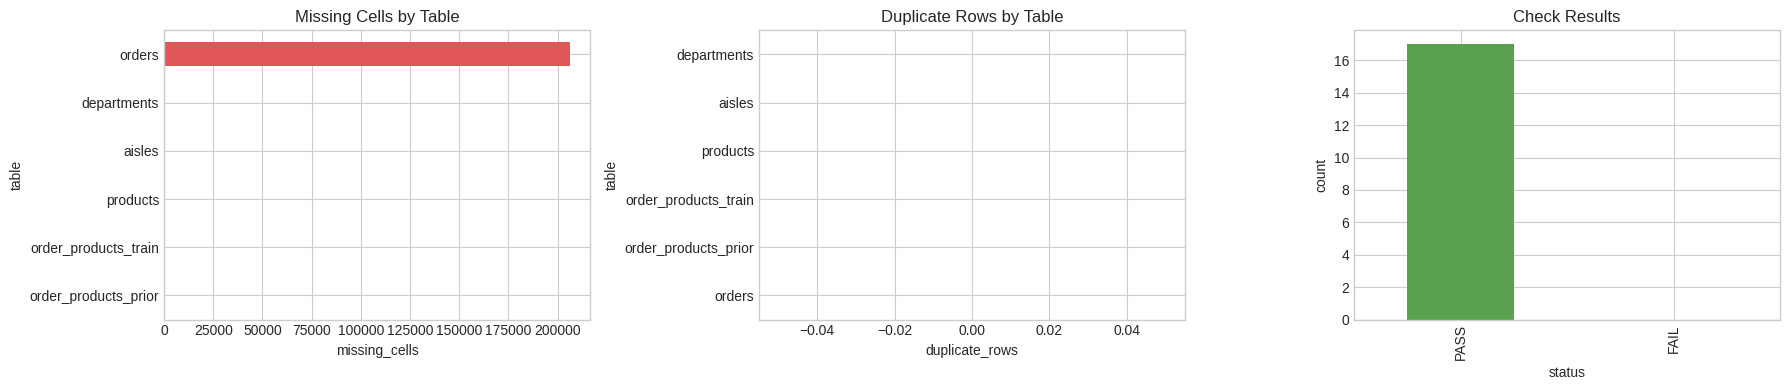

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

profile_df.sort_values('missing_cells', ascending=True).plot(
    x='table', y='missing_cells', kind='barh', ax=axes[0], color='#E15759', legend=False
)
axes[0].set_title('Missing Cells by Table')
axes[0].set_xlabel('missing_cells')
axes[0].set_ylabel('table')

profile_df.sort_values('duplicate_rows', ascending=True).plot(
    x='table', y='duplicate_rows', kind='barh', ax=axes[1], color='#4E79A7', legend=False
)
axes[1].set_title('Duplicate Rows by Table')
axes[1].set_xlabel('duplicate_rows')
axes[1].set_ylabel('table')

checks_df['status'].value_counts().reindex(['PASS', 'FAIL'], fill_value=0).plot(
    kind='bar', ax=axes[2], color=['#59A14F', '#E15759']
)
axes[2].set_title('Check Results')
axes[2].set_xlabel('status')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

## 7) Export Quality Artifacts

In [11]:
# Persist quality artifacts for downstream use (monitoring/reporting)
output_dir_candidates = [Path('data/processed/quality'), Path('../../data/processed/quality')]
output_dir = output_dir_candidates[0] if output_dir_candidates[0].parent.exists() else output_dir_candidates[1]
output_dir.mkdir(parents=True, exist_ok=True)

profile_df.to_csv(output_dir / 'table_profile.csv', index=False)
missing_df.to_csv(output_dir / 'column_missing.csv', index=False)
checks_df.to_csv(output_dir / 'check_results.csv', index=False)
issue_register.to_csv(output_dir / 'issue_register.csv', index=False)

imputation_df.to_csv(output_dir / 'imputation_log.csv', index=False)
missing_comparison.to_csv(output_dir / 'missing_comparison_before_after.csv', index=False)

# Export cleaned tables after approved imputations
for table_name, df in clean_tables.items():
    df.to_csv(output_dir / f'{table_name}_clean.csv', index=False)

print(f'Quality artifacts and cleaned data exported to: {output_dir.resolve()}')

Quality artifacts and cleaned data exported to: /home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/data/processed/quality


## 8) Executive Summary Template
After running all cells, summarize:
- number of total checks, pass rate, fail rate
- count of critical and major issues
- top 3 issues by impact (invalid_count)
- go/no-go decision before feature engineering
- remediation plan owner and ETA

In [12]:
summary_kpi = pd.Series({
    'total_checks': int(len(checks_df)),
    'pass_checks': int((checks_df['status'] == 'PASS').sum()),
    'fail_checks': int((checks_df['status'] == 'FAIL').sum()),
    'pass_rate_pct': round((checks_df['status'] == 'PASS').mean() * 100, 2),
    'critical_failures': int(((checks_df['status'] == 'FAIL') & (checks_df['severity'] == 'critical')).sum()),
    'major_failures': int(((checks_df['status'] == 'FAIL') & (checks_df['severity'] == 'major')).sum()),
})

summary_kpi

total_checks         17.0000
pass_checks          17.0000
fail_checks           0.0000
pass_rate_pct       100.0000
critical_failures     0.0000
major_failures        0.0000
dtype: float64